# Data & Packages

In [1]:
# Main Packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy

# Clustering 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, adjusted_rand_score, mutual_info_score

# Optimisation 
from scipy.optimize import linear_sum_assignment

# Parallel processing 
from joblib import Parallel, delayed

# Counting 
from collections import Counter

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

In [4]:
# Time conversions
seconds_in_day = 60 * 60 * 24
eight_weeks_seconds = 8 * 7 * seconds_in_day

# Time aggregation
agg_hour_level = 1/6

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [5]:
# Keep the first 8 weeks of data
df = df.filter(pl.col("time") <= eight_weeks_seconds)

In [6]:
# Chosen features
feature_cols = [
    'log_n_events',
    'log_n_distinct_src',
    'log_n_distinct_dest',
    'failure_ratio',
    'c_bar',
    's_bar',
    ]

# Functions

In [7]:
# Build the features dataframe
def build_features(df,agg_hour_level):

    agg_seconds = agg_hour_level * 60 * 60 

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day)/seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user','bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
            log_n_events = pl.col('n_events').log(),
            log_n_distinct_src = pl.col('n_distinct_src').log(),
            log_n_distinct_dest = pl.col('n_distinct_dest').log(),
        ).collect()
        )

In [8]:
# Process features for clustering
def cluster_preprocess(features_df, X_scaled, week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    in_bin = features_df['bucket'].is_between(lb,ub).to_numpy()

    features_week = features_df.filter(in_bin)
    X_scaled_week = X_scaled[in_bin]

    return features_week, X_scaled_week 

In [9]:
# FUNCTION - kmeans 
def fit_kmeans(k, Y):
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(Y)
    ch  = calinski_harabasz_score(Y, labels)    
    return k, ch

# Clustering

### Process features

In [10]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [11]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Choose k 

In [12]:
# # Cluster for each week and get optimal k
# n_weeks = 8
# optimal_k = []

# for week in range(1, n_weeks + 1):

#     features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

#     results = Parallel(n_jobs = -1)(delayed(fit_kmeans)(k, X_scaled_week) for k in range(2,11))
    
#     best_result = max(results, key = lambda row: row[1])
#     best_k, best_score  = best_result[0], best_result[1]
#     optimal_k.append(best_k)

#     print(f"Week {week}: optimal k = {best_k}, CH_score = {best_score:.4f}")

In [13]:
# # Counts for optimal k
# k_counts = Counter(optimal_k)
# modal_k, modal_count = k_counts.most_common(1)[0]

### Cluster

In [14]:
# Cluster for each week 
n_weeks = 8
k = 2
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

# Cluster Stability Metrics

### User Overlap

In [23]:
# Cluster sizes on the overlap set, per week
cluster_sizes = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next, on=['src_user','relative_bucket'], how='inner', suffix='_next')

    sizes_curr = overlap.group_by('cluster').len().sort('cluster')
    sizes_next = overlap.group_by('cluster_next').len().sort('cluster_next')

    cluster_sizes[week] = {
        'curr': dict(zip(sizes_curr['cluster'], sizes_curr['len'])),
        'next': dict(zip(sizes_next['cluster_next'], sizes_next['len'])),
    }

    print(f"Week {week} (curr) sizes: {cluster_sizes[week]['curr']}")
    print(f"Week {week+1} (next) sizes: {cluster_sizes[week]['next']}")

Week 1 (curr) sizes: {0: 549650, 1: 518913}
Week 2 (next) sizes: {0: 524084, 1: 544479}
Week 2 (curr) sizes: {0: 499843, 1: 527860}
Week 3 (next) sizes: {0: 499245, 1: 528458}
Week 3 (curr) sizes: {0: 503125, 1: 518510}
Week 4 (next) sizes: {0: 531478, 1: 490157}
Week 4 (curr) sizes: {0: 630348, 1: 572777}
Week 5 (next) sizes: {0: 651704, 1: 551421}
Week 5 (curr) sizes: {0: 667732, 1: 581510}
Week 6 (next) sizes: {0: 601309, 1: 647933}
Week 6 (curr) sizes: {0: 609290, 1: 604444}
Week 7 (next) sizes: {0: 1189160, 1: 24574}
Week 7 (curr) sizes: {0: 1144270, 1: 34191}
Week 8 (next) sizes: {0: 611374, 1: 567087}


In [15]:
# Percentage overlap on consectuive weeks
overlap_percentages = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')
    
    union = len(w_curr) + len(w_next) - len(overlap)

    overlap_percentages[week] = len(overlap)/union
    
    print(f"  Overlap: {len(overlap)} week {week} pairs ({len(overlap)/union:.2%})")

  Overlap: 1068563 week 1 pairs (29.88%)
  Overlap: 1027703 week 2 pairs (29.04%)
  Overlap: 1021635 week 3 pairs (29.39%)
  Overlap: 1203125 week 4 pairs (32.46%)
  Overlap: 1249242 week 5 pairs (32.32%)
  Overlap: 1213734 week 6 pairs (30.51%)
  Overlap: 1178461 week 7 pairs (29.48%)


In [16]:
# Average overlap of users across weeks
print(np.array(list(overlap_percentages.values())).mean())

0.30438581177659035


### Adjusted Rand Index (ARI)  

In [17]:
# ARI (clustering stability )scores
ARI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')


    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()
    
    ARI = adjusted_rand_score(labels_curr, labels_next)

    ARI_scores[(week, week + 1)] = ARI

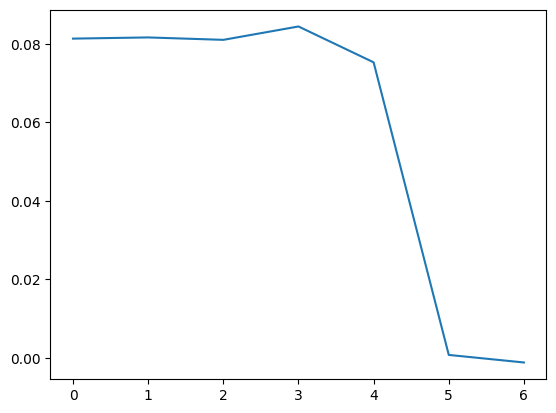

In [18]:
plt.plot(ARI_scores.values())

### Variation of Information

In [19]:
def cluster_entropy(labels):
    _, counts = np.unique(labels, return_counts = True) 
    return scipy.stats.entropy(counts)

def variation_of_information(labels_1, labels_2):

    H_1 = cluster_entropy(labels_1)
    H_2 = cluster_entropy(labels_2)
    MI = mutual_info_score(labels_1,labels_2)

    return H_1 + H_2 - 2 * MI

In [20]:
# VI scores
VI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')

    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()

    VI = variation_of_information(labels_curr, labels_next)

    VI_scores[(week, week + 1)] = VI

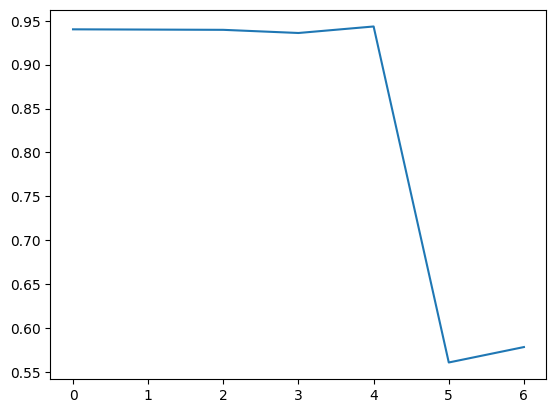

In [21]:
plt.plot(np.array(list(VI_scores.values()))/(2*np.log(2)))